# Simulation électrostatique FEM — Électrodes coplanaires

Calcul de la distribution de potentiel électrique et du champ électrique dans un isolant avec des électrodes coplanaires placées sur la face supérieure.

**Méthode :** Éléments finis éléments triangulaires linéaires  
**Géométrie :** Capteur capacitif avec électrodes coplanaires

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import spsolve
from matplotlib.tri import Triangulation
import matplotlib.patches as patches

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

## 2. Classe principale `CoplanarElectrodesFEM`

In [2]:
class CoplanarElectrodesFEM:
    """
    FEM pour électrostatique avec électrodes coplanaires sur la face supérieure.
    Résout l'équation de Laplace : ∇·(ε∇φ) = 0
    """

    def __init__(self, use_electrode2=False, length=1.0, height=0.5,
                 nx=40, ny=20, electrode1_pos=(0.2, 0.4),
                 electrode2_pos=None, epsilon_r=4.0):
        """
        Parameters
        ----------
        use_electrode2 : bool
            Active la deuxième électrode.
        length, height : float
            Dimensions du domaine (m).
        nx, ny : int
            Nombre de nœuds dans chaque direction.
        electrode1_pos, electrode2_pos : tuple (x_start, x_end)
            Positions des électrodes sur la face supérieure.
        epsilon_r : float
            Permittivité relative de l'isolant.
        """
        self.use_electrode2 = use_electrode2
        self.length = length
        self.height = height
        self.nx = nx
        self.ny = ny
        self.electrode1_pos = electrode1_pos
        self.electrode2_pos = electrode2_pos
        self.epsilon_r = epsilon_r
        self.epsilon_0 = 8.854187817e-12  # F/m
        self.generate_mesh()

    # ------------------------------------------------------------------
    # Maillage
    # ------------------------------------------------------------------

    def generate_mesh(self):
        """Génère un maillage triangulaire structuré (2 triangles par cellule)."""
        x = np.linspace(0, self.length, self.nx)
        y = np.linspace(0, self.height, self.ny)
        X, Y = np.meshgrid(x, y)

        self.nodes = np.column_stack([X.ravel(), Y.ravel()])
        self.n_nodes = len(self.nodes)

        triangles = []
        for j in range(self.ny - 1):
            for i in range(self.nx - 1):
                n0 = j * self.nx + i
                n1 = j * self.nx + (i + 1)
                n2 = (j + 1) * self.nx + (i + 1)
                n3 = (j + 1) * self.nx + i
                triangles.append([n0, n1, n3])
                triangles.append([n1, n2, n3])

        self.elements = np.array(triangles)
        self.n_elements = len(self.elements)

        top_mask = np.abs(self.nodes[:, 1] - self.height) < 1e-10
        top_idx  = np.where(top_mask)[0]

        x1s, x1e = self.electrode1_pos
        self.electrode1_nodes = top_idx[
            (self.nodes[top_idx, 0] >= x1s) & (self.nodes[top_idx, 0] <= x1e)
        ]

        if self.use_electrode2 and self.electrode2_pos is not None:
            x2s, x2e = self.electrode2_pos
            self.electrode2_nodes = top_idx[
                (self.nodes[top_idx, 0] >= x2s) & (self.nodes[top_idx, 0] <= x2e)
            ]
        else:
            self.electrode2_nodes = np.array([])

        self.bottom_nodes = np.where(np.abs(self.nodes[:, 1]) < 1e-10)[0]

        print(f"Maillage : {self.n_nodes} nœuds, {self.n_elements} éléments")
        print(f"Électrode 1 : {len(self.electrode1_nodes)} nœuds  "
              f"(x ∈ [{x1s:.2f}, {x1e:.2f}] m)")
        if self.use_electrode2:
            print(f"Électrode 2 : {len(self.electrode2_nodes)} nœuds  "
                  f"(x ∈ [{x2s:.2f}, {x2e:.2f}] m)")

    # ------------------------------------------------------------------
    # Assemblage FEM
    # ------------------------------------------------------------------

    def local_stiffness_matrix(self, elem_nodes):
        """Matrice de rigidité locale 3×3 pour un triangle linéaire."""
        (x1, y1), (x2, y2), (x3, y3) = elem_nodes
        area = 0.5 * abs((x2 - x1) * (y3 - y1) - (x3 - x1) * (y2 - y1))
        if area < 1e-15:
            return np.zeros((3, 3))

        b = np.array([y2 - y3, y3 - y1, y1 - y2])
        c = np.array([x3 - x2, x1 - x3, x2 - x1])
        eps = self.epsilon_0 * self.epsilon_r

        K_loc = np.zeros((3, 3))
        for i in range(3):
            for j in range(3):
                K_loc[i, j] = (eps / (4 * area)) * (b[i]*b[j] + c[i]*c[j])
        return K_loc

    def assemble_global_matrix(self):
        """Assemble la matrice de rigidité globale (sparse)."""
        K = lil_matrix((self.n_nodes, self.n_nodes))
        for elem in self.elements:
            K_loc = self.local_stiffness_matrix(self.nodes[elem])
            for i in range(3):
                for j in range(3):
                    K[elem[i], elem[j]] += K_loc[i, j]
        return K.tocsr()

    # ------------------------------------------------------------------
    # Conditions aux limites & résolution
    # ------------------------------------------------------------------

    def apply_boundary_conditions(self, K, F,
                                   V_electrode1=100.0,
                                   V_electrode2=0.0,
                                   V_bottom=0.0):
        """Conditions de Dirichlet par substitution directe."""
        K_mod = K.tolil()
        F_mod = F.copy()

        def impose(node, val):
            K_mod[node, :] = 0
            K_mod[node, node] = 1
            F_mod[node] = val

        for node in self.electrode1_nodes:
            impose(node, V_electrode1)
        if self.use_electrode2:
            for node in self.electrode2_nodes:
                impose(node, V_electrode2)
        for node in self.bottom_nodes:
            impose(node, V_bottom)

        return K_mod.tocsr(), F_mod

    def solve(self, V_electrode1=100.0, V_electrode2=0.0, V_bottom=0.0):
        """Assemble et résout le système linéaire."""
        print("Assemblage de la matrice globale...")
        K = self.assemble_global_matrix()
        F = np.zeros(self.n_nodes)

        print("Application des conditions aux limites...")
        K_mod, F_mod = self.apply_boundary_conditions(
            K, F, V_electrode1, V_electrode2, V_bottom)

        print("Résolution du système linéaire...")
        self.phi = spsolve(K_mod, F_mod)
        print(f"φ ∈ [{self.phi.min():.3f}, {self.phi.max():.3f}] V")
        return self.phi

    # ------------------------------------------------------------------
    # Champ électrique
    # ------------------------------------------------------------------

    def compute_electric_field(self):
        """Calcule E = -∇φ par élément (valeur constante par triangle)."""
        E = np.zeros((self.n_elements, 2))
        for k, elem in enumerate(self.elements):
            (x1,y1),(x2,y2),(x3,y3) = self.nodes[elem]
            p1, p2, p3 = self.phi[elem]
            area = 0.5 * abs((x2-x1)*(y3-y1) - (x3-x1)*(y2-y1))
            if area < 1e-15:
                continue
            b = np.array([y2-y3, y3-y1, y1-y2])
            c = np.array([x3-x2, x1-x3, x2-x1])
            E[k, 0] = -(b[0]*p1 + b[1]*p2 + b[2]*p3) / (2*area)
            E[k, 1] = -(c[0]*p1 + c[1]*p2 + c[2]*p3) / (2*area)
        self.E_field = E
        Emag = np.linalg.norm(E, axis=1)
        print(f"|E| max = {Emag.max():.2f} V/m")
        return E

    # ------------------------------------------------------------------
    # Visualisation
    # ------------------------------------------------------------------

    def plot_results(self, V_electrode1=100.0, V_electrode2=0.0,
                     V_bottom=0.0, x_cuts=None):
        """Génère les deux figures de résultats."""
        tri = Triangulation(self.nodes[:, 0], self.nodes[:, 1], self.elements)
        x1s, x1e = self.electrode1_pos
        if self.use_electrode2:
            x2s, x2e = self.electrode2_pos

        # ── Figure 1 : maillage / potentiel / équipotentielles ──────────
        fig = plt.figure(figsize=(20, 6))
        fig.subplots_adjust(left=0.06, right=0.97, top=0.88,
                            bottom=0.12, wspace=0.45)
        levels = np.linspace(self.phi.min(), self.phi.max(), 25)

        # — Maillage —
        ax1 = fig.add_subplot(131)
        ax1.triplot(tri, 'k-', linewidth=0.2, alpha=0.3)
        ax1.add_patch(patches.Rectangle(
            (x1s, self.height - 0.01), x1e - x1s, 0.02,
            lw=2, edgecolor='red', facecolor='red', alpha=0.7,
            label=f'Électrode 1 ({V_electrode1} V)'))
        if self.use_electrode2:
            ax1.add_patch(patches.Rectangle(
                (x2s, self.height - 0.01), x2e - x2s, 0.02,
                lw=2, edgecolor='blue', facecolor='blue', alpha=0.7,
                label=f'Électrode 2 ({V_electrode2} V)'))
        ax1.plot(self.nodes[self.electrode1_nodes, 0],
                 self.nodes[self.electrode1_nodes, 1], 'ro', ms=4, alpha=0.8)
        if self.use_electrode2:
            ax1.plot(self.nodes[self.electrode2_nodes, 0],
                     self.nodes[self.electrode2_nodes, 1], 'bo', ms=4, alpha=0.8)
        ax1.set(xlabel='x (m)', ylabel='y (m)')
        ax1.set_title('Maillage avec électrodes\ncoplanaires',
                      fontsize=11, fontweight='bold', pad=8)
        ax1.set_xlim(0, self.length)
        ax1.set_ylim(0, self.height)
        ax1.legend(fontsize=8, loc='lower left')
        ax1.set_aspect('equal')
        ax1.grid(True, alpha=0.2)
        ax1.tick_params(labelsize=9)

        # — Potentiel —
        ax2 = fig.add_subplot(132)
        cf2 = ax2.tricontourf(tri, self.phi, levels=levels, cmap='RdYlBu_r')
        cb2 = plt.colorbar(cf2, ax=ax2, fraction=0.046, pad=0.04)
        cb2.set_label('Potentiel φ (V)', fontsize=9)
        cb2.ax.tick_params(labelsize=8)
        ax2.add_patch(patches.Rectangle(
            (x1s, self.height - 0.01), x1e - x1s, 0.02,
            lw=2, edgecolor='red', facecolor='red', alpha=0.8))
        if self.use_electrode2:
            ax2.add_patch(patches.Rectangle(
                (x2s, self.height - 0.01), x2e - x2s, 0.02,
                lw=2, edgecolor='blue', facecolor='blue', alpha=0.8))
        ax2.set(xlabel='x (m)', ylabel='y (m)')
        ax2.set_title('Distribution du potentiel\nélectrique',
                      fontsize=11, fontweight='bold', pad=8)
        ax2.set_aspect('equal')
        ax2.tick_params(labelsize=9)

        # — Équipotentielles —
        ax3 = fig.add_subplot(133)
        cf3 = ax3.tricontourf(tri, self.phi, levels=levels,
                              cmap='RdYlBu_r', alpha=0.6)
        ax3.tricontour(tri, self.phi, levels=20,
                       colors='black', linewidths=1, alpha=0.8)
        cb3 = plt.colorbar(cf3, ax=ax3, fraction=0.046, pad=0.04)
        cb3.set_label('Potentiel φ (V)', fontsize=9)
        cb3.ax.tick_params(labelsize=8)
        ax3.set(xlabel='x (m)', ylabel='y (m)')
        ax3.set_title('Lignes équipotentielles',
                      fontsize=11, fontweight='bold', pad=8)
        ax3.set_aspect('equal')
        ax3.tick_params(labelsize=9)

        plt.savefig('coplanar_electrodes_results.png', dpi=150,
                    bbox_inches='tight')
        plt.show()
        print("Figure 1 sauvegardée : coplanar_electrodes_results.png")

        # ── Figure 2 : profils V(y) et V(x) ────────────────────────────
        fig2, (ax_cut, ax_h) = plt.subplots(1, 2, figsize=(14, 5))
        fig2.subplots_adjust(left=0.08, right=0.97, top=0.88,
                             bottom=0.13, wspace=0.35)

        if x_cuts is not None:
            x_cuts_used = x_cuts
        else:
            x_cuts_used = [round(self.length * f, 3)
                           for f in [0.1, 0.3, 0.5, 0.7, 0.9]]

        for xc in x_cuts_used:
            if not (0 <= xc <= self.length):
                raise ValueError(
                    f"x_cuts contient {xc} m hors du domaine "
                    f"[0, {self.length}] m.")

        tol = self.length / (4 * self.nx)
        colors_vy = plt.cm.tab10(np.linspace(0, 0.9, len(x_cuts_used)))
        x_mesh = np.unique(self.nodes[:, 0])

        for xc, col in zip(x_cuts_used, colors_vy):
            xc_snap = x_mesh[np.argmin(np.abs(x_mesh - xc))]
            mask    = np.abs(self.nodes[:, 0] - xc_snap) < tol
            y_v, p_v = self.nodes[mask, 1], self.phi[mask]
            si = np.argsort(y_v)
            ax_cut.plot(y_v[si], p_v[si], '-o', color=col,
                        lw=2, ms=4, label=f'x = {xc_snap:.3f} m')

        ax_cut.axvline(self.height, ls='--', color='red', alpha=0.6,
                       label=f'Face sup. (y = {self.height} m)')
        ax_cut.axvline(0, ls='--', color='black', alpha=0.6,
                       label=f'Face inf. — V = {V_bottom} V')
        ax_cut.set(xlabel='y (m)', ylabel='Potentiel φ (V)',
                   xlim=(0, self.height))
        ax_cut.set_title('Profils V(y) à différentes\nabscisses x',
                         fontsize=11, fontweight='bold', pad=8)
        ax_cut.set_xlim(0, self.height)
        ax_cut.legend(fontsize=8)
        ax_cut.grid(True, alpha=0.3)
        ax_cut.tick_params(labelsize=9)

        for h in [0.2 * self.height, 0.5 * self.height, 0.8 * self.height]:
            tol_h  = self.height / (4 * self.ny)
            mask_h = np.abs(self.nodes[:, 1] - h) < tol_h
            x_h, p_h = self.nodes[mask_h, 0], self.phi[mask_h]
            si = np.argsort(x_h)
            ax_h.plot(x_h[si], p_h[si], '-o', lw=2, ms=3,
                      label=f'y = {h:.2f} m')

        ax_h.axvspan(self.electrode1_pos[0], self.electrode1_pos[1],
                     alpha=0.2, color='red', label='Électrode 1')
        if self.use_electrode2 and self.electrode2_pos is not None:
            ax_h.axvspan(self.electrode2_pos[0], self.electrode2_pos[1],
                         alpha=0.2, color='blue', label='Électrode 2')
        ax_h.set(xlabel='Position x (m)', ylabel='Potentiel φ (V)')
        ax_h.set_title('Profils V(x) à différentes\nhauteurs',
                       fontsize=11, fontweight='bold', pad=8)
        ax_h.set_xlim(0, self.length)
        ax_h.legend(fontsize=8)
        ax_h.grid(True, alpha=0.3)
        ax_h.tick_params(labelsize=9)

        plt.savefig('coplanar_electrodes_profiles.png', dpi=150,
                    bbox_inches='tight')
        plt.show()
        print("Figure 2 sauvegardée : coplanar_electrodes_profiles.png")

## 3. Paramètres de simulation

Modifier les cellules ci-dessous pour configurer la géométrie, les résolutions et les tensions.

In [3]:
# ── Géométrie du domaine ────────────────────────────────────────────────────
LENGTH   = 1.0   # longueur (m)
HEIGHT   = 0.5   # hauteur (m)

# ── Résolution du maillage ──────────────────────────────────────────────────
NX = 60          # nœuds en x  (↑ = plus précis, plus lent)
NY = 40          # nœuds en y

# ── Matériau ────────────────────────────────────────────────────────────────
EPSILON_R = 4.0  # permittivité relative de l'isolant

# ── Électrodes ──────────────────────────────────────────────────────────────
ELECTRODE1_POS = (0.4, 0.6)   # (x_start, x_end) en mètres
ELECTRODE2_POS = None         # mettre ex. (0.7, 0.9) pour activer
USE_ELECTRODE2 = False

# ── Tensions (V) ────────────────────────────────────────────────────────────
V_ELECTRODE1 = 1.0
V_ELECTRODE2 = -100.0
V_BOTTOM     = 0.0            # face inférieure (référence)

# ── Profils V(y) ────────────────────────────────────────────────────────────
# Liste d'abscisses x (m) pour les coupes verticales.
# Mettre None pour un choix automatique (5 positions régulières).
X_CUTS = None   # exemple : [0.2, 0.4, 0.5, 0.6, 0.8]

## 4. Initialisation & génération du maillage

In [4]:
fem = CoplanarElectrodesFEM(
    use_electrode2 = USE_ELECTRODE2,
    length         = LENGTH,
    height         = HEIGHT,
    nx             = NX,
    ny             = NY,
    electrode1_pos = ELECTRODE1_POS,
    electrode2_pos = ELECTRODE2_POS,
    epsilon_r      = EPSILON_R,
)

Maillage : 2400 nœuds, 4602 éléments
Électrode 1 : 12 nœuds  (x ∈ [0.40, 0.60] m)


## 5. Résolution du système FEM

In [5]:
phi = fem.solve(V_ELECTRODE1, V_ELECTRODE2, V_BOTTOM)

Assemblage de la matrice globale...
Application des conditions aux limites...
Résolution du système linéaire...
φ ∈ [0.000, 1.000] V


## 6. Calcul du champ électrique

In [6]:
E = fem.compute_electric_field()

|E| max = 12.89 V/m


## 7. Visualisation des résultats

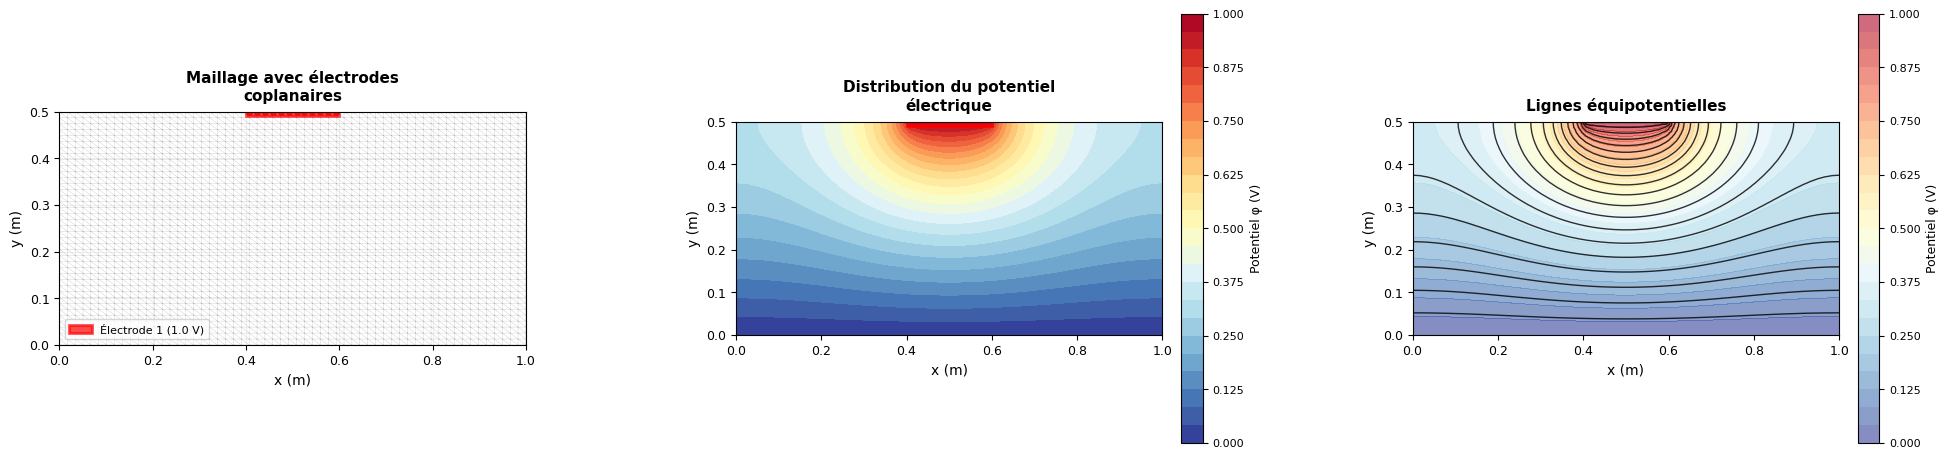

Figure 1 sauvegardée : coplanar_electrodes_results.png


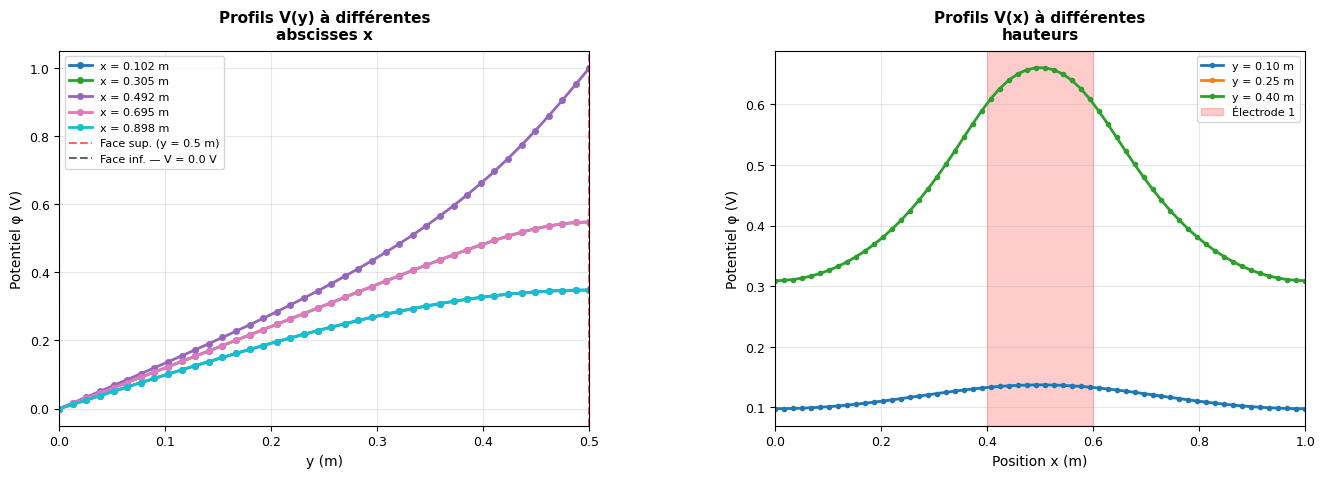

Figure 2 sauvegardée : coplanar_electrodes_profiles.png


In [7]:
fem.plot_results(V_ELECTRODE1, V_ELECTRODE2, V_BOTTOM, x_cuts=X_CUTS)

## 8. Sauvegarde des données

In [8]:
np.savez(
    'coplanar_data.npz',
    nodes           = fem.nodes,
    elements        = fem.elements,
    phi             = phi,
    E_field         = E,
    electrode1_nodes= fem.electrode1_nodes,
    electrode2_nodes= fem.electrode2_nodes,
    parameters      = {
        'length'      : LENGTH,
        'height'      : HEIGHT,
        'electrode1_pos': ELECTRODE1_POS,
        'electrode2_pos': ELECTRODE2_POS,
        'epsilon_r'   : EPSILON_R,
        'V_electrode1': V_ELECTRODE1,
        'V_electrode2': V_ELECTRODE2,
        'V_bottom'    : V_BOTTOM,
    },
)
print("Données sauvegardées : coplanar_data.npz")

Données sauvegardées : coplanar_data.npz
